# Workshop Part 2: Data Preparation

## Learning Objectives
- Clean and prepare data for analysis
- Handle missing values and duplicates
- Perform text preprocessing for ML
- Create sentiment labels from ratings
- Save intermediate cleaned data

## Data Scientist's Role
"You just saw what is wrong (we also explained it) and now we have to make it right!"

We'll correct the problems identified in Part 1 and prepare the data for machine learning.

In [26]:
# Workshop Progress Tracker
notebooks = ["01 Extract", "02 Prepare", "03 Storage", "04 ML", "05 Deploy"]
current = 1  # This is notebook 02

print("="*70)
print("📊 WORKSHOP PROGRESS")
print("="*70)
for i, nb in enumerate(notebooks):
    if i < current:
        print(f"✅ {nb}")
    elif i == current:
        print(f"👉 {nb} ← YOU ARE HERE")
    else:
        print(f"⬜ {nb}")
print("="*70)

📊 WORKSHOP PROGRESS
✅ 01 Extract
👉 02 Prepare ← YOU ARE HERE
⬜ 03 Storage
⬜ 04 ML
⬜ 05 Deploy


## Step 1: Load the Merged Data

In Notebook 01, we extracted and merged data from three sources. Now we need to load that merged data for cleaning.

**Note:** In a production ETL pipeline, you would typically:
1. Save the merged data from Notebook 01 to a file
2. Load it here in Notebook 02

For this workshop, we'll re-merge the files to ensure everyone has the data.

In [27]:
import pandas as pd
import numpy as np
import re

# Load merged data from Notebook 01
# In a real workflow, you would either:
# 1. Load the merged data from a saved file, OR
# 2. Re-run the merge from the three source files

# For this workshop, we'll reload and merge the three files
print("📊 Loading data from three source systems...")
reviews = pd.read_csv('../data/raw/reviews.csv')
inventory = pd.read_csv('../data/raw/inventory.csv')
sales = pd.read_csv('../data/raw/sales.csv')

print("🔄 Merging datasets...")
# Merge reviews + inventory
reviews_inventory = reviews.merge(
    inventory,
    on=['product_id', 'product_name', 'date'],
    how='left'
)

# Merge with sales
df = reviews_inventory.merge(
    sales,
    on=['product_id', 'product_name', 'date'],
    how='left'
)

print(f"✅ Merged dataset loaded: {len(df)} reviews")
print(f"Missing review_text: {df['review_text'].isnull().sum()}")
print(f"Missing sales_volume: {df['sales_volume'].isnull().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")

📊 Loading data from three source systems...
🔄 Merging datasets...
✅ Merged dataset loaded: 773 reviews
Missing review_text: 0
Missing sales_volume: 7
Duplicate rows: 33


## Step 2: Handle Missing Values

We have two options for missing values:
1. **Drop rows** - Remove rows with missing critical data
2. **Impute** - Fill missing values with reasonable estimates

For our use case:
- **review_text**: Drop rows (we can't analyze sentiment without text)
- **sales_volume**: Impute with product mean (preserves data for discount calculation)

In [28]:
# Group decision making
print("="*70)
print("🗳️  GROUP DECISION: How should we handle missing data?")
print("="*70)
print(f"\nThe Situation:")
print(f"  • {df['review_text'].isnull().sum()} reviews are missing text ({(df['review_text'].isnull().sum()/len(df)*100):.1f}%)")
print(f"  • {df['sales_volume'].isnull().sum()} reviews are missing sales volume ({(df['sales_volume'].isnull().sum()/len(df)*100):.1f}%)")
print(f"\n📊 Missing review_text: We NEED text for sentiment analysis")
print("   ✅ Decision: DROP these rows (no choice here!)")
print(f"\n💰 Missing sales_volume: We could use this for weighting discounts")
print("   Options:")
print("   A) Drop rows (lose data, but clean)")
print("   B) Fill with mean sales (preserve data, reasonable guess) ← We'll use this")
print("   C) Fill with median sales (robust to outliers)")
print("   D) Fill with 0 (pessimistic, 'no sales')")
print("\n⏱️  Take 30 seconds to discuss with your neighbor.")
print("💬 Question: Why might option B (mean) be better than option D (zero)?")
print("="*70)

🗳️  GROUP DECISION: How should we handle missing data?

The Situation:
  • 0 reviews are missing text (0.0%)
  • 7 reviews are missing sales volume (0.9%)

📊 Missing review_text: We NEED text for sentiment analysis
   ✅ Decision: DROP these rows (no choice here!)

💰 Missing sales_volume: We could use this for weighting discounts
   Options:
   A) Drop rows (lose data, but clean)
   B) Fill with mean sales (preserve data, reasonable guess) ← We'll use this
   C) Fill with median sales (robust to outliers)
   D) Fill with 0 (pessimistic, 'no sales')

⏱️  Take 30 seconds to discuss with your neighbor.
💬 Question: Why might option B (mean) be better than option D (zero)?


### 🗳️ GROUP DECISION: Missing Data Strategy

Before we handle missing data, let's discuss our options as a group!

In [29]:
# Drop rows with missing review_text (critical for sentiment analysis)
df_cleaned = df.dropna(subset=['review_text']).copy()

print(f"After dropping missing review_text: {len(df_cleaned)} reviews")
print(f"Removed {len(df) - len(df_cleaned)} rows")

After dropping missing review_text: 773 reviews
Removed 0 rows


In [30]:
# Impute missing sales_volume with product mean
for product in df_cleaned['product_name'].unique():
    product_mask = df_cleaned['product_name'] == product
    mean_sales = df_cleaned.loc[product_mask, 'sales_volume'].mean()
    df_cleaned.loc[product_mask & df_cleaned['sales_volume'].isnull(), 'sales_volume'] = mean_sales

print(f"\nMissing values after imputation:")
print(df_cleaned.isnull().sum())


Missing values after imputation:
product_id      0
product_name    0
date            0
rating          0
review_text     0
stock_level     0
sales_volume    0
dtype: int64


## Step 3: Remove Duplicate Reviews

In [31]:
# Remove duplicate rows
before_dedup = len(df_cleaned)
df_cleaned = df_cleaned.drop_duplicates()
after_dedup = len(df_cleaned)

print(f"Duplicates removed: {before_dedup - after_dedup}")
print(f"Dataset size after deduplication: {after_dedup} reviews")

Duplicates removed: 33
Dataset size after deduplication: 740 reviews


## Step 4: Text Preprocessing

Clean and normalize review text for machine learning:
1. Convert to lowercase
2. Remove extra whitespace
3. Remove special characters (keep only letters and basic punctuation)

In [32]:
def clean_text(text):
    """
    Clean and normalize text for ML processing
    """
    if pd.isnull(text):
        return ""
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    # Keep only letters, spaces, and basic punctuation
    text = re.sub(r'[^a-z\s.,!?]', '', text)
    
    return text

# Apply text cleaning
df_cleaned['review_text_clean'] = df_cleaned['review_text'].apply(clean_text)

# Show examples
print("Examples of cleaned text:")
print("=" * 80)
for i in range(3):
    print(f"\nOriginal: {df_cleaned['review_text'].iloc[i]}")
    print(f"Cleaned:  {df_cleaned['review_text_clean'].iloc[i]}")

Examples of cleaned text:

Original: Love these tomatoes! Always consistent quality.
Cleaned:  love these tomatoes! always consistent quality.

Original: Average quality potatoes. Not bad but not great.
Cleaned:  average quality potatoes. not bad but not great.

Original: Superb quality! These broccoli are wonderful.
Cleaned:  superb quality! these broccoli are wonderful.


## Step 5: Create Sentiment Labels

Convert star ratings to sentiment categories:
- **Negative**: 1-2 stars
- **Neutral**: 3 stars
- **Positive**: 4-5 stars

In [33]:
def rating_to_sentiment(rating):
    """
    Convert star rating to sentiment label
    """
    if rating <= 2:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    else:  # 4-5
        return 'positive'

# Create sentiment labels
df_cleaned['sentiment'] = df_cleaned['rating'].apply(rating_to_sentiment)

print("Sentiment Distribution:")
print("=" * 50)
print(df_cleaned['sentiment'].value_counts())
print(f"\nPercentages:")
print(df_cleaned['sentiment'].value_counts(normalize=True) * 100)

Sentiment Distribution:
sentiment
positive    441
neutral     192
negative    107
Name: count, dtype: int64

Percentages:
sentiment
positive    59.594595
neutral     25.945946
negative    14.459459
Name: proportion, dtype: float64


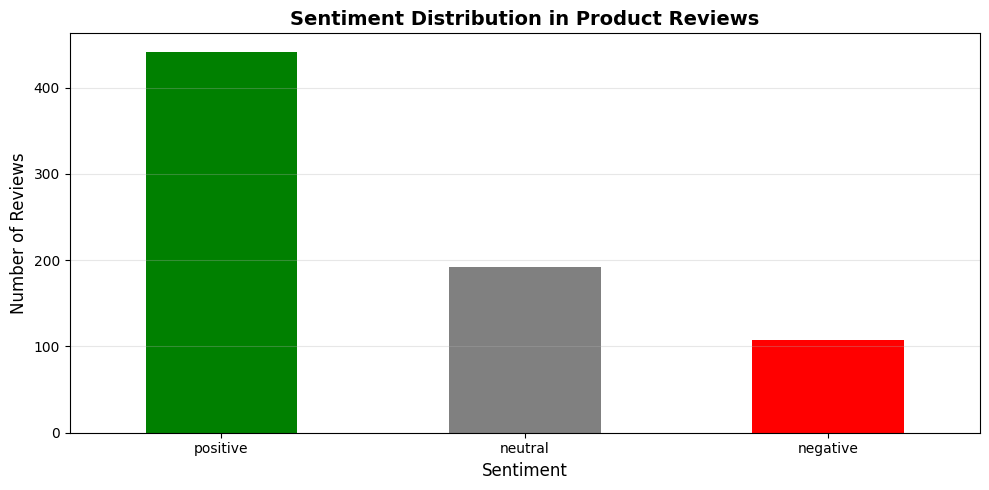

In [34]:
# Visualize sentiment distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sentiment_counts = df_cleaned['sentiment'].value_counts()
colors = {'positive': 'green', 'neutral': 'gray', 'negative': 'red'}
sentiment_colors = [colors[sent] for sent in sentiment_counts.index]

sentiment_counts.plot(kind='bar', color=sentiment_colors)
plt.title('Sentiment Distribution in Product Reviews', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
# Let students experiment
print("="*70)
print("🔬 EXPERIMENT: What if we change sentiment boundaries?")
print("="*70)
print("\nCurrently: 1-2★ = Negative | 3★ = Neutral | 4-5★ = Positive")
print("\n🤔 QUESTION: Should 3-star reviews count as 'neutral' or 'positive'?")
print("   Argument for NEUTRAL: It's middle-of-the-road, not great")
print("   Argument for POSITIVE: 3/5 is a passing grade, customer was satisfied")
print("\n💡 Let's see the impact of both approaches:")

# Show current distribution
current_dist = df_cleaned['sentiment'].value_counts()
print(f"\n📊 CURRENT APPROACH (3★ = Neutral):")
for sent in ['positive', 'neutral', 'negative']:
    if sent in current_dist.index:
        pct = (current_dist.get(sent, 0) / len(df_cleaned)) * 100
        print(f"   {sent.capitalize():10}: {current_dist.get(sent, 0):3} reviews ({pct:.1f}%)")

# Alternative: 3-star as positive
df_alt = df_cleaned.copy()
df_alt.loc[df_alt['rating'] == 3, 'sentiment_alt'] = 'positive'
df_alt['sentiment_alt'] = df_alt['sentiment_alt'].fillna(df_alt['sentiment'])
alt_dist = df_alt['sentiment_alt'].value_counts()

print(f"\n📊 ALTERNATIVE (3★ = Positive):")
for sent in ['positive', 'neutral', 'negative']:
    if sent in alt_dist.index:
        pct = (alt_dist.get(sent, 0) / len(df_cleaned)) * 100
        print(f"   {sent.capitalize():10}: {alt_dist.get(sent, 0):3} reviews ({pct:.1f}%)")

print(f"\n💰 BUSINESS IMPACT:")
print(f"   Current approach → {current_dist.get('negative', 0)} reviews get high discounts (50-90%)")
print(f"   Alternative     → {alt_dist.get('negative', 0)} reviews get high discounts (50-90%)")
print(f"   Difference: No change in negative reviews, but neutral→positive shift")
print(f"\n🗳️  Quick poll: Which approach makes more sense for discount decisions?")
print("💬 Discuss: Would customers giving 3★ want a discount or not?")
print("="*70)

🔬 EXPERIMENT: What if we change sentiment boundaries?

Currently: 1-2★ = Negative | 3★ = Neutral | 4-5★ = Positive

🤔 QUESTION: Should 3-star reviews count as 'neutral' or 'positive'?
   Argument for NEUTRAL: It's middle-of-the-road, not great
   Argument for POSITIVE: 3/5 is a passing grade, customer was satisfied

💡 Let's see the impact of both approaches:

📊 CURRENT APPROACH (3★ = Neutral):
   Positive  : 441 reviews (59.6%)
   Neutral   : 192 reviews (25.9%)
   Negative  : 107 reviews (14.5%)

📊 ALTERNATIVE (3★ = Positive):
   Positive  : 633 reviews (85.5%)
   Negative  : 107 reviews (14.5%)

💰 BUSINESS IMPACT:
   Current approach → 107 reviews get high discounts (50-90%)
   Alternative     → 107 reviews get high discounts (50-90%)
   Difference: No change in negative reviews, but neutral→positive shift

🗳️  Quick poll: Which approach makes more sense for discount decisions?
💬 Discuss: Would customers giving 3★ want a discount or not?


### 🔬 EXPERIMENT: What if we change sentiment boundaries?

Let's explore how our choice of sentiment thresholds affects the results!

## Step 6: Feature Engineering

Create additional features that might be useful for analysis:
- Review length (number of characters)
- Review word count

In [36]:
# Create additional features
df_cleaned['review_length'] = df_cleaned['review_text_clean'].str.len()
df_cleaned['review_word_count'] = df_cleaned['review_text_clean'].str.split().str.len()

# Show statistics by sentiment
print("Review Length Statistics by Sentiment:")
print("=" * 50)
print(df_cleaned.groupby('sentiment')[['review_length', 'review_word_count']].mean())

Review Length Statistics by Sentiment:
           review_length  review_word_count
sentiment                                  
negative       42.700935           7.084112
neutral        36.927083           5.833333
positive       46.287982           6.802721


## Step 7: Save Intermediate Cleaned Data

This creates intermediate data step per step to a table "cleaned up name"

### Why Save Intermediate Data?
1. **Reproducibility**: Can restart analysis from this point without re-cleaning
2. **Debugging**: Easier to identify issues in later steps
3. **Collaboration**: Team members can use cleaned data directly
4. **Performance**: Don't need to re-run expensive cleaning operations

In [37]:
print("="*70)
print("🎯 QUICK RECAP: Test Your Understanding")
print("="*70)
print("\n❓ DISCUSSION QUESTIONS (Talk with your neighbor for 1-2 minutes):")
print("\n1. Why did we impute sales_volume but DROP missing review_text?")
print("   Hint: One is critical for our analysis, the other is optional.")
print("\n2. How does text cleaning help machine learning?")
print("   Hint: 'Best' vs 'BEST!' vs 'best' - should these be treated differently?")
print("\n3. What business decision depends on our 3-star sentiment choice?")
print("   Hint: Think about discount percentages.")
print("\n✅ Ready? Let's move to Notebook 03: Storage Theory!")
print("="*70)

🎯 QUICK RECAP: Test Your Understanding

❓ DISCUSSION QUESTIONS (Talk with your neighbor for 1-2 minutes):

1. Why did we impute sales_volume but DROP missing review_text?
   Hint: One is critical for our analysis, the other is optional.

2. How does text cleaning help machine learning?
   Hint: 'Best' vs 'BEST!' vs 'best' - should these be treated differently?

3. What business decision depends on our 3-star sentiment choice?
   Hint: Think about discount percentages.

✅ Ready? Let's move to Notebook 03: Storage Theory!


## 🎯 Quick Recap: Test Your Understanding

Take 1-2 minutes to discuss these questions with your neighbor:

In [38]:
# Select relevant columns for the cleaned dataset
columns_to_save = [
    'product_id', 'product_name', 'review_text', 'review_text_clean',
    'rating', 'sentiment', 'date', 'sales_volume', 'stock_level',
    'review_length', 'review_word_count'
]

df_final = df_cleaned[columns_to_save].copy()

# Save to CSV
df_final.to_csv('../data/cleaned/cleaned_reviews.csv', index=False)

print(f"Cleaned data saved successfully!")
print(f"Final dataset size: {len(df_final)} reviews")
print(f"\nColumns in cleaned dataset:")
print(df_final.columns.tolist())

Cleaned data saved successfully!
Final dataset size: 740 reviews

Columns in cleaned dataset:
['product_id', 'product_name', 'review_text', 'review_text_clean', 'rating', 'sentiment', 'date', 'sales_volume', 'stock_level', 'review_length', 'review_word_count']


## Step 8: Data Preparation Summary

In [39]:
print("DATA PREPARATION SUMMARY")
print("=" * 80)
print(f"Original dataset: {len(df)} reviews")
print(f"Final cleaned dataset: {len(df_final)} reviews")
print(f"Rows removed: {len(df) - len(df_final)} ({((len(df) - len(df_final)) / len(df) * 100):.2f}%)")
print(f"\nData Quality Improvements:")
print(f"  - Removed rows with missing review text")
print(f"  - Imputed missing sales volumes")
print(f"  - Removed duplicate reviews")
print(f"  - Cleaned and normalized text data")
print(f"  - Created sentiment labels from ratings")
print(f"  - Added feature engineering (review length, word count)")
print(f"\nOutput: ../data/cleaned/cleaned_reviews.csv")

DATA PREPARATION SUMMARY
Original dataset: 773 reviews
Final cleaned dataset: 740 reviews
Rows removed: 33 (4.27%)

Data Quality Improvements:
  - Removed rows with missing review text
  - Imputed missing sales volumes
  - Removed duplicate reviews
  - Cleaned and normalized text data
  - Created sentiment labels from ratings
  - Added feature engineering (review length, word count)

Output: ../data/cleaned/cleaned_reviews.csv


In [40]:
# Preview final cleaned data
print("\nFinal Cleaned Data Preview:")
print("=" * 80)
df_final.head()


Final Cleaned Data Preview:


,product_id,product_name,review_text,review_text_clean,rating,sentiment,date,sales_volume,stock_level,review_length,review_word_count
0,4,Tomatoes,Love these tomatoes! Always consistent quality.,love these tomatoes! always consistent quality.,4,positive,2025-10-28,213.0,127,47,6
1,1,Potatoes,Average quality potatoes. Not bad but not great.,average quality potatoes. not bad but not great.,3,neutral,2025-10-15,234.0,156,48,8
2,6,Broccoli,Superb quality! These broccoli are wonderful.,superb quality! these broccoli are wonderful.,4,positive,2025-12-10,313.0,108,45,6
3,6,Broccoli,"The broccoli are alright, nothing to complain ...","the broccoli are alright, nothing to complain ...",3,neutral,2025-12-01,233.0,133,52,8
4,2,Carrots,"The carrots are okay, I've had better.","the carrots are okay, ive had better.",3,neutral,2025-11-09,119.0,159,37,7


## At the End: Clean Data Created

We have successfully prepared the data for machine learning! The cleaned dataset is ready for:
1. **Storage** (discussed in next notebook)
2. **ML Model Training** (sentiment analysis)
3. **Discount Recommendation** (based on sentiment)

## Key Takeaways

- **Data Cleaning**: Essential step before any analysis or ML
- **Missing Values**: Different strategies (drop vs. impute) depending on the column
- **Text Preprocessing**: Normalize text for consistent ML input
- **Feature Engineering**: Create useful features from raw data
- **Intermediate Storage**: Save cleaned data for reproducibility and efficiency

## Next Steps

In the next notebook (03_storage_theory.ipynb), we'll discuss:
- Where to store different types of data
- Cloud storage options (Azure Blob Storage)
- Data lifecycle management
- Real-world example: AH Dynamic Markdown architecture